# Expfit notes 1: Initial estimate for single exponential

To derive good initial estimates in a wide variety of situations, we use the following strategy:

(1) **Transformations**. To avoid numerical issues with very large or very small numbers, we transform the data onto the unit square. In extreme cases (e.g. rapidly increasing exponentials), we use a second transformation that "zooms in" on the section of the data where most change occurs.

(2) **Two-point estimate**. With two points and their derivatives $(x_i, y_i, y_i'=\frac{dy}{dx}\rvert_i)$ we have enough information to define an expontial.

(3) **Least-squares estimate of derivatives**. To obtain $y'_i$ in noisy data, we select two _segments_ $S_i$ of the data, fit straight lines with linear least squares, and then use the slope as our derivatives. Similarly, $x_i$ and $y_i$ will be set as the mean $x$ and $y$ of these segments.

(4) **Use a heuristic to select good segments**. To select $S_1$ and $S_2$, we split the dataset down the middle, using the start as $S_1$ and the end as $S_2$. From the slopes of these lines, we can already see if the data is likely exponential: the slopes should have the same sign, and the (absolute) slope on $S_2$ will be larger for an increasing exponential, smaller for a decaying exponential. Next, we iteratively shrink each segment, until the influence of noise outweighs the increased precision of the linear estimate.

## Requirements on input

We require a time series $(x, y)$ where $x$ and $y$ are 1-dimensional vectors of the same size, and $x$ either has length 0 or is strictly increasing.

**For the time being, we try to allow irregularly sampled data, although tests are currently on regularly sampled.**

## Single exponential equation

For the initial estimate, we use
\begin{align}
y = a + b e^{c x}
\end{align}

## 1. Calculating $a$, $b$, and $c$

\begin{align}
y(x)  &= a + b e^{c x} \\
y'(x) &= c b e^{c x}
\end{align}

**Given** two points $(x_1, y_1)$ and $(x_2, y_2)$ and their slopes $y_1'$ and $y_2'$
\begin{align}
y_1  - y_2  &= b (e^{c x_1} - e^{c x_2}) \\
y_1' - y_2' &= c b (e^{c x_1} - e^{c x_2}) \\
c &= \frac{y_1' - y_2'}{y_1 - y_2} \\
b &= \frac{y_1 - y_2}{e^{cx_1} - e^{cx_2}} \\
a &= y_i - b e^{cx_i} \qquad i \in \{1, 2\}
\end{align}

In the test cases,  that the choice of $i$ to determine $a$ made a negligible difference.

### Alternatives

An earlier version used
\begin{align}
b = \frac{y'_i}{c}e^{-cx_i}  \qquad i \in \{1, 2\}
\end{align}
but this was abandoned due to sensitivity of $y'_i$ to noise, reflected in a strong influence of the choice of $i$.

Another equation for $a$ is
\begin{align}
a &= y_1 - \frac{y'_1}{c} \qquad i \in \{1, 2\}
\end{align}
which avoids an exponentiation but again includes a derivative, so is more noise-sensitive.

### Straight lines

A `NotExponentialError` is raised if $y'_1 = y'_2$ or $y_1 = y_2$.

The MSE for the obtained parameters ($E_\text{exp}$) is calculated, and compared to the MSE for a straight line fit ($E_\text{ls}$).
A `NotExponentialError` is raised if
- $E_\text{ls} \leq E_\text{exp} \frac{2 + n}{n}$, or
- $E_\text{exp} = 0$ and $E_\text{ls} / A_0 < 10^{-9}$

The first criterion is based on the Akaike information criterion (see Model Selection notebook).
The second uses the area under the data, $A_0$, and is an ad-hoc solution for the edge case where $E_\text{exp} = 0$, but $E_\text{ls}$ is negligible.

## 2. Finding two points and their derivatives

To find $(x_1, y_1, y_1')$ and $(x_2, y_2, y_2')$ we select a segment $S_1$ at the start of the data, and a segment $S_2$ at the end of the data.

1. $x_i$ and $y_i$ are the mean of $t$ and $v$ on $S_i$
2. $y_i'$ is found by fitting a straight line to $S_i$ with linear least squares


### Finding segments

To find segments that provide a good approximation for the slope, we select two initial segments, $S_1$ and $S_2$, from the full data set $S_0$.
These are chosen as the first ($S_1$) and second ($S_2$) half of $S_0$.
Next, we follow the procedure outlined below to iteratively shrink segment, stopping when the proposed next segment appears no longer meets certain criteria.

**Edge case**: If $S_0$ contains an odd number of points, we allow $S_1$ and $S_2$ to overlap in one point. This is advantageous for very short $S_0$.

Linear least squares fits $L_i = \{s_i, o_i\}$ are performed for $i = 0, 1, 2$, where $s_i$ is a slope and $o_i$ is an offset.
For a time series (predominantly) containing an exponential, we expect that (1) the slopes $s_0$, $s_1$, and $s_2$ have the same sign.

**Edge case**: If $s_1$ or $s_2$ has a different sign to $s_0$, this is assumed due to noise or some other corrupting signal. In this case, the slope is set to 0, and no further reduction of this segment is performed.

**Magic numbers**: Using half the data initially, shrinking factor 0.5

#### Shrinking

To propose a new segment $\tilde{S}_i$, we halve the current segment. For $S_1$ we retain the initial half, for $S_2$ the second.

**Condition 1**. A linear least squares fit is then performed on the proposed segment.
If this has a different slope than the current segment, the proposal is rejected and the shrinking procedure ends.

**Condition 2**. The $a$, $b$, and $c$ parameters are estimated, the area under the exponential is calculated and compared to the area under the data ($A_0$). The proposal is rejected if the area under the curve estimate is worse than before.

## 3. Demo

First, create some data:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import expfit

In [2]:
rng = np.random.default_rng(2)

def f(x, a, b, c):
    return a + b * np.exp(c * x)

def fn(x, a, b, c, s):
    y = f(x, a, b, c)
    return y + (y[-1] - y[0]) * rng.normal(0, s, len(x))


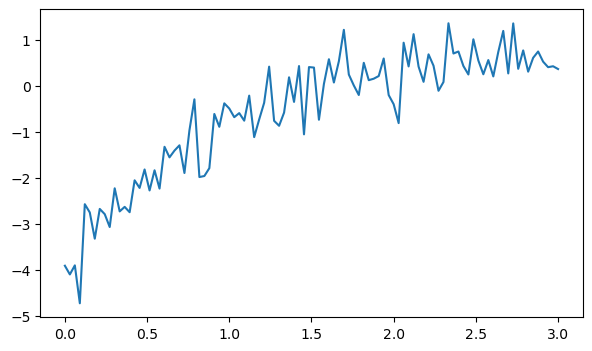

In [3]:
a, b, c = 1, -5, -1
s = 0.1
x = np.linspace(0, 3, 100)
y = fn(x, a, b, c, s)

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot()
ax.plot(x, y)
plt.show()

Next, we demonstrate the shrinking procedure:

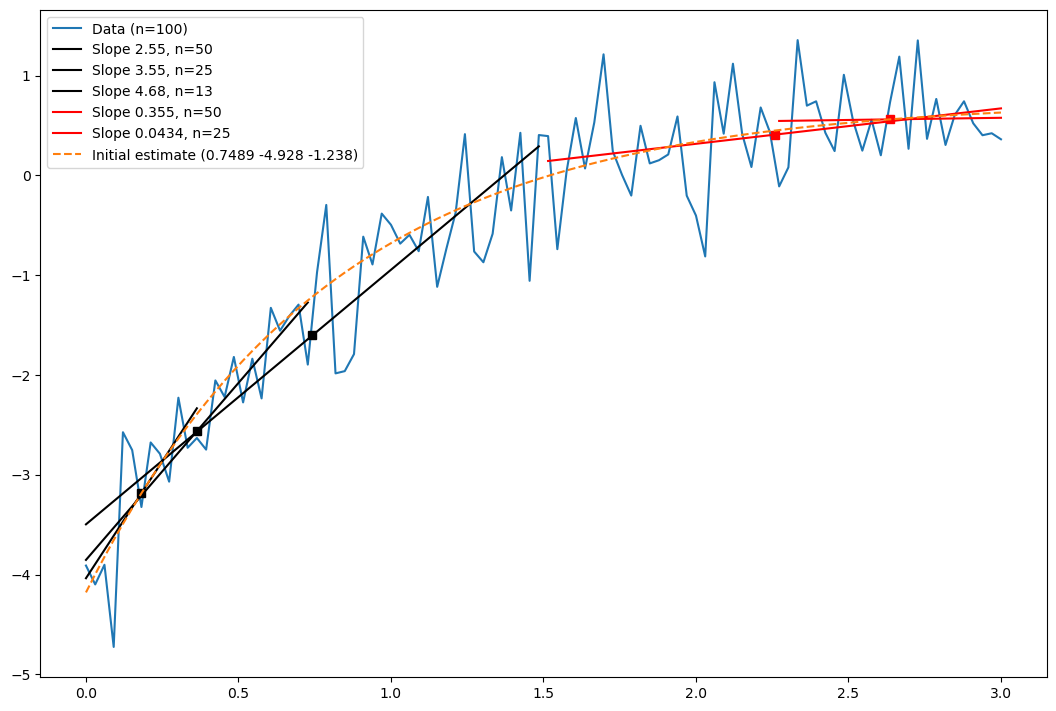

In [4]:
a, b, c = expfit.estimate_initial_single(x, y, plot=True)

Note that this shows the initial segment, the accepted proposals, and finally the rejected (and last) proposal.

Next, we show the segments selected this way on four different test cases:

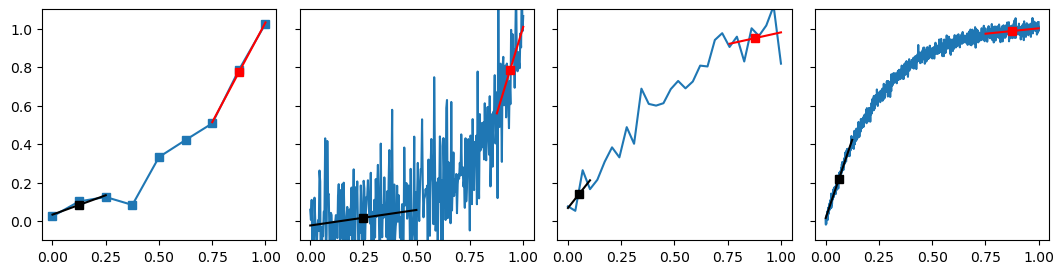

In [5]:
rng = np.random.default_rng(1)

tests = [
    (3, 2, 2, 0.07, 9),
    (-3, 5, 4, 0.2, 300),
    (-1, -2, -2, 0.08, 30),
    (4, -2, -4, 0.02, 1200),
]

def fnorm(x, a, b, c, s):
    # Version of fn that normalises y to [0, 1], approximately
    y = f(x, a, b, c)
    return (y - y[0]) / (y[-1] - y[0]) + rng.normal(0, s, len(x))

fig = plt.figure(figsize=(13, 3))
fig.subplots_adjust(wspace=0.1)
grd = fig.add_gridspec(1, 4)

for i, (a, b, c, s, n) in enumerate(tests):
    x = np.linspace(0, 1, n)
    y = fnorm(x, a, b, c, s)

    ax = fig.add_subplot(grd[i])
    ax.set_ylim(-0.1, 1.1)
    if i > 0:
        ax.set_yticklabels([])

    ax.plot(x, y, 's-' if n < 10 else '-')
    r = expfit.estimate_initial_single(x, y, full=True)
    ax.plot(r.ls1.x, r.ls1.y, 'k')
    ax.plot(r.ls2.x, r.ls2.y, 'r')
    ax.plot(r.ls1.mu_x, r.ls1.mu_y, 'ks')
    ax.plot(r.ls2.mu_x, r.ls2.mu_y, 'rs')

plt.show()

Note that we have normalised the data here, causing all examples (note the different signs etc.) to look very similar.

Now, we run again showing the initial guesses.

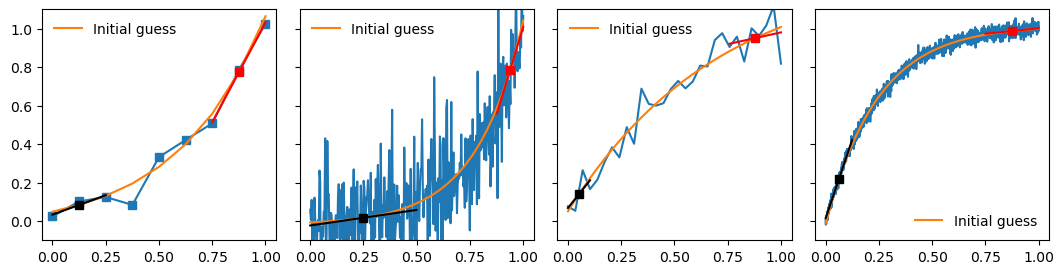

In [6]:
rng = np.random.default_rng(1)

fig = plt.figure(figsize=(13, 3))
fig.subplots_adjust(wspace=0.1)
grd = fig.add_gridspec(1, 4)
for i, (a, b, c, s, n) in enumerate(tests):
    x = np.linspace(0, 1, n)
    y = fnorm(x, a, b, c, s)

    ax = fig.add_subplot(grd[i])
    ax.plot(x, y, 's-' if n < 10 else '-')
    a0, b0, c0 = r = expfit.estimate_initial_single(x, y, full=True)
    ax.plot(x, f(x, a0, b0, c0), label='Initial guess')
    ax.plot(r.ls1.x, r.ls1.y, 'k')
    ax.plot(r.ls2.x, r.ls2.y, 'r')
    ax.plot(r.ls1.mu_x, r.ls1.mu_y, 'ks')
    ax.plot(r.ls2.mu_x, r.ls2.mu_y, 'rs')    
    ax.legend(frameon=False)
    ax.set_ylim(-0.1, 1.1)
    if i > 0:
        ax.set_yticklabels([])

plt.show()

### Harder cases

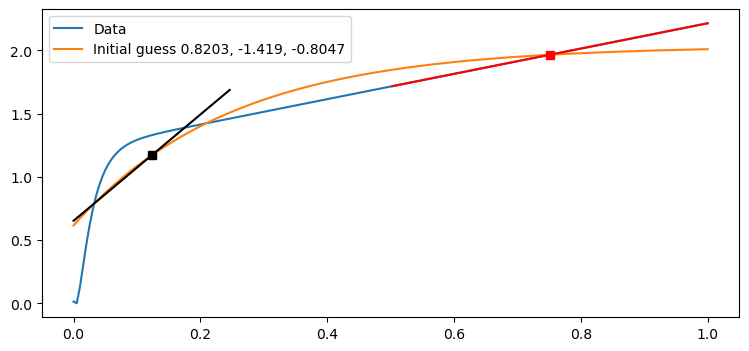

In [7]:
a0, b0, c0 = 1, -2, -9
x = np.linspace(0, 5, 200)
y = a0 * np.zeros(x.shape)
y += b0 * np.exp(c0 * x)
y += 0.8 * np.exp(-30 * x)
y +=- -0.2 * x

def demo(x, y):
    x, y = tr = expfit.UnitSquaredSeries(x, y)
    fig = plt.figure(figsize=(9, 4))
    ax = fig.add_subplot()
    ax.plot(x, y, label='Data')
    a, b, c = r = expfit.estimate_initial_single(x, y, full=True)
    u, v, w = tr.detransform((a, b, c))
    ax.plot(x, a + b * np.exp(c * x), label=f'Initial guess {u:.4}, {v:.4}, {w:.4}')
    ax.plot(r.ls1.x, r.ls1.y, 'k')
    ax.plot(r.ls2.x, r.ls2.y, 'r')
    ax.plot(r.ls1.mu_x, r.ls1.mu_y, 'ks')
    ax.plot(r.ls2.mu_x, r.ls2.mu_y, 'rs')
    ax.legend()

demo(x, y)
plt.show()

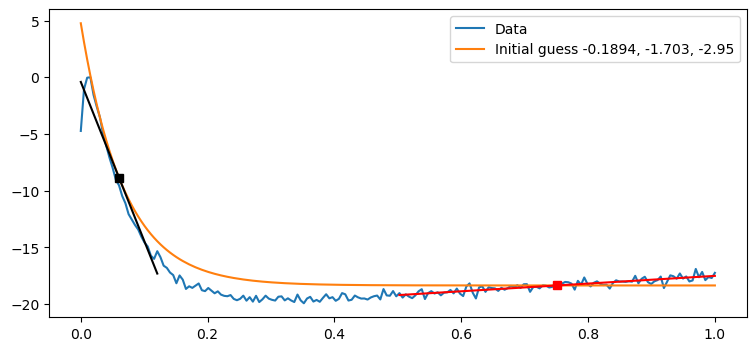

In [8]:
rng = np.random.default_rng(1)

a0, b0, c0 = 1, -2, -3
x = np.linspace(0, 5, 200)
y = a0 * np.zeros(x.shape)
y += b0 * np.exp(c0 * x)
y += 0.8 * np.exp(-30 * x)
y +=- 0.05 * x
y += rng.normal(0, 0.02, y.shape)

demo(x, y)
plt.show()

Next, a really big sine.

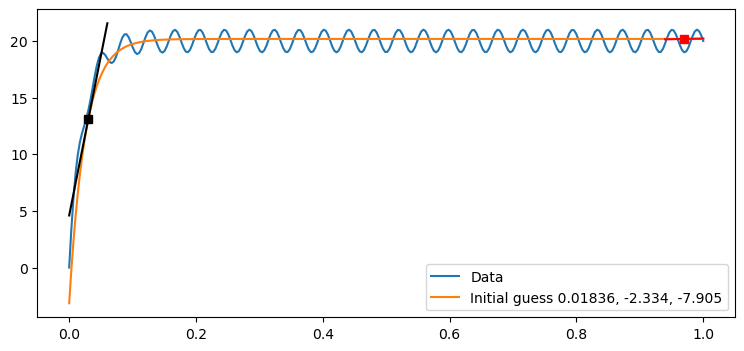

In [9]:
a0, b0, c0 = 1, -2, -9
x = np.linspace(0, 5, 300)
y = a0 * np.zeros(x.shape)
y += b0 * np.exp(c0 * x)
y += 0.1 * np.sin(10.2 * np.pi * x)

demo(x, y)

## Straight lines

A similar sine, on a flat line:

No exponential found in time series: Straight line


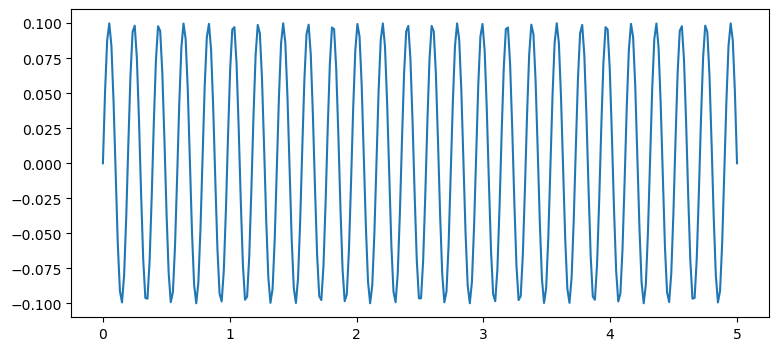

In [10]:
a0, b0, c0 = 1, -2, -9
x = np.linspace(0, 5, 300)
y = a0 * np.zeros(x.shape)
y += 0.1 * np.sin(10.2 * np.pi * x)

fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot()
ax.plot(x, y, label='Data')

try:
    expfit.estimate_initial_single(expfit.UnitSquaredSeries(x, y))
except Exception as e:
    print(e)

A flat line with noise:

No exponential found in time series: Straight line


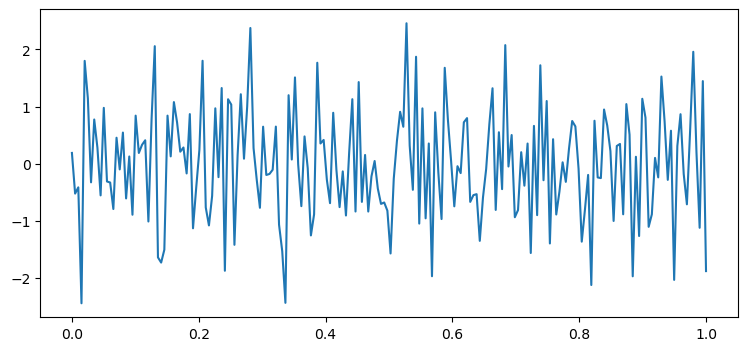

In [11]:
rng = np.random.default_rng(2)
x = np.linspace(0, 1, 200)
y = 3 * np.zeros(x.shape)
y += rng.normal(0, 1, x.shape)

fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot()
ax.plot(x, y, label='Data')

try:
    expfit.estimate_initial_single(expfit.UnitSquaredSeries(x, y))
except Exception as e:
    print(e)

### Autocorrelated noise

So far we've used Gaussian noise.
_For previous versions, which used normality of the residuals in decision making, this could have been a problem_.

We can try other noise types too:

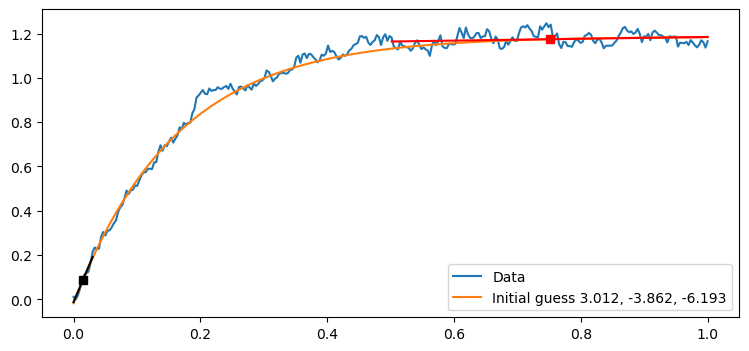

In [12]:
a0, b0, c0 = 3, -4, -7
x = np.linspace(0, 1, 300)
y = a0 + b0 * np.exp(c0 * x)

# Add AR1 noise (https://pints.readthedocs.io/en/stable/noise_generators.html)
rng = np.random.default_rng(5)
rho, sigma = 0.8, 0.1
s = sigma * np.sqrt(1 - rho**2)
v = rng.normal(0, s, len(x))
v[0] = rng.uniform()
for t in range(1, len(x)):
    v[t] += rho * v[t - 1]
y += v

demo(x, y)

## Unit square transformation

Before fitting **single** exponentials, a transformation is performed to:

1. Avoid extreme numbers, especially when $b$ and $c$ (or optimiser guesses of $b$ and $c$) are large.
2. Allow magic number based heuristics (although not currently used)

The time series $(x, y)$ is mapped onto an approximate unit square:

\begin{align}
\tilde{x} = \frac{x - x_0}{x_{n-1} - x_0} \equiv \frac{x - x_0}{r_x} &&
\tilde{y} = \frac{y - y_0}{\max(y) - \min(y)} \equiv \frac{v - y_0}{r_y}
\end{align}

Because $x$ is guaranteed to be strictly increasing, this places $\tilde{x}$ on the range $[0, 1]$

**Edge case:** If $r_y = 0$ (exactly) we set $r_y = 1$.

### Detransforming obtained parameters

Having found parameters $\tilde{a}, \tilde{b}, \tilde{c}$ in the transformed space, we have
\begin{align}
\tilde{y} &= \tilde{a} + \tilde{b} \exp(\tilde{c} \tilde{x}) \\
\frac{y - y_0}{r_y} &= \tilde{a} + \tilde{b} \exp\left(\tilde{c} \frac{x - x_0}{r_x} \right) \\
y &= y_0 + r_y \tilde{a} + \tilde{b} r_y \exp\left(-\frac{\tilde{c} x_0}{r_x}\right) \exp\left(\frac{\tilde{c}}{r_x}x\right) \\
  &= a + b e^{c x} \\
\end{align}
for
\begin{align}
a = y_0 + r_y \tilde{a} &&
b = \tilde{b} r_y  \exp[-\tilde{c} x_0 / r_x] &&
c = \tilde{c} / r_x
\end{align}
which lets us detransform parameters obtained in the transformed space.

For debugging, we can plot the known solution in the transformed space, with:
\begin{align}
\tilde{a} = \frac{a - y_0}{r_y} && 
\tilde{b} = \frac{b}{r_y} \exp[c x_0] && 
\tilde{c} = c r_x
\end{align}

**Note:** The transformations for $b$ and $c$ extend to $b_i$ and $c_i$ for multiple exponentials.

### Zooming in on steep areas

If the exponential is exceptionally steep, the estimates can go very far off.
To compensate for this, we add a second transform (used only inside the initial estimate routine), that isolates a segment where most of the action happens, at either the start or the end of the signal.

We start with signal $S_0$ with length $n$.
The initial subsegments are $S_1 = S_0[:m]$ and $S_2 = S_0[m:]$ where $m = \lfloor n / 2 \rfloor$, with ranges $r_i = \max(S_i) - \min(S_i)$

```
m = n // 2
s1, s2 = v[:m], v[m:]
r1, r2 = range_of(s1), range_of(s2)
if r1 / r2 > 20:
    while r1 / r2 > 20:
        m = \max(m // 2, 1)
        s1, s2 = v[:m], v[m:]
        r1, r2 = range_of(s1), range_of(s2)
elif r2 / r1 > 20:
    # Same, but at end of signal

if selection made, and selection longer than n_min:
    accept
else:
    reject
```

### Demo

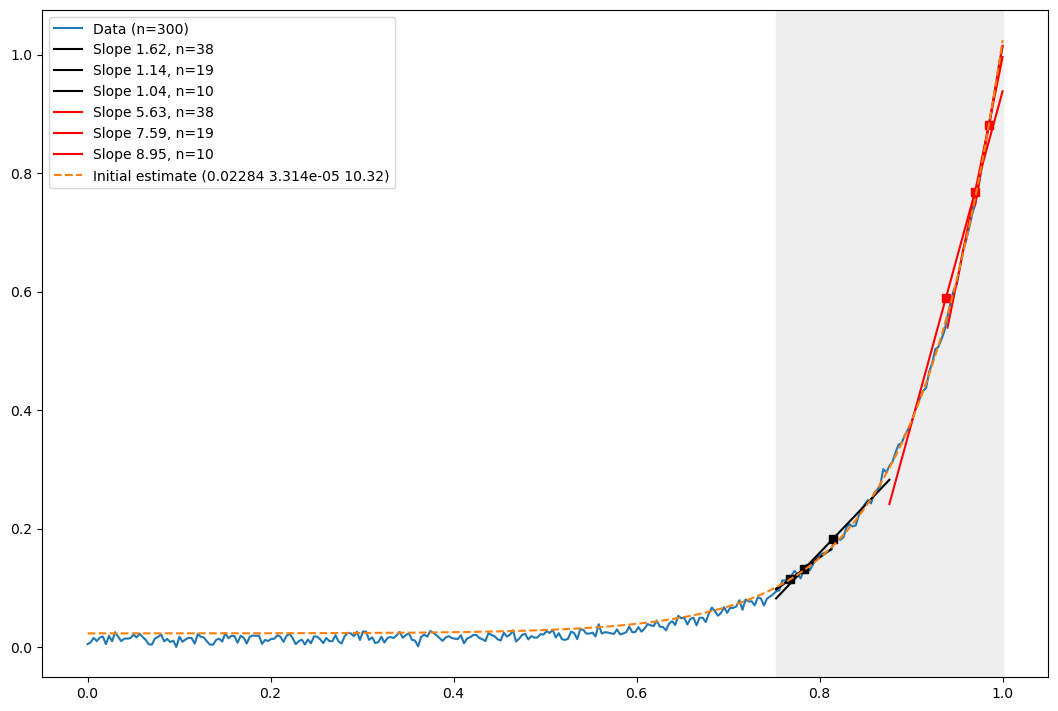

In [16]:
rng = np.random.default_rng(15)

a0, b0, c0 = 3, 4, 10
x = np.linspace(0, 1, 300)
y = a0 + b0 * np.exp(c0 * x)
y += rng.normal(0, 5e2, y.shape)

x, y = tr = expfit.UnitSquaredSeries(x, y)
r = expfit.estimate_initial_single(x, y, plot=True)

Here, the shaded area is the segment selected by the transform.
As can be seen from the slope segments, `estimate_initial_single` operates within these bounds.